In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import N_LABELS
from ugdatalab.methods.neural_network.cnn import train_cnn, count_parameters
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop, GpuRandomRotation360

from architectures import build_resnet18, build_custom_cnn
import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — Data Augmentation (Task 21)

This notebook is the second half of the optimisation experiments started in `05a-scheduler.ipynb`. It runs:

1. An **augmentation-only quick test** for 50 epochs (constant LR, no scheduler) — the augmentation-axis counterpart to the scheduler-only run in 05a. Together these two quick tests, plus the unaugmented NB-04 baseline, make a clean 2×2 ablation across the two optimisations.
2. A **final 100-epoch combined run** with both rotation augmentation and the `ReduceLROnPlateau` scheduler enabled. This is the model that is carried into `06-evaluation.ipynb`.

Galaxy morphological labels are rotationally invariant — a spiral galaxy is still a spiral when rotated — so random rotation is a natural augmentation that generates valid training examples without changing labels. This effectively increases the size of the training set, reducing overfitting.

Target: RMSE $\leq 0.09$ (good), $\leq 0.08$ (excellent).

In [2]:
# Load preprocessed data
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]
split_data = np.load("artifacts/split_indices.npz")
train_idx, val_idx = split_data["train_idx"], split_data["val_idx"]

train_images, val_images = images[train_idx], images[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]
CACHE_SIZE = images.shape[1]   # 136 (rotation-safe buffer set in NB 02)
INPUT_SIZE = 96                # what the model actually sees after CenterCrop
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Augmentation + scheduler experiments target the Custom CNN by request.
custom_data = np.load("artifacts/custom_result.npz", allow_pickle=True)
BEST_MODEL_NAME = "Custom CNN"
_n_channels = [int(x) for x in custom_data["n_channels_list"]]
_kernels = [int(x) for x in custom_data["kernel_sizes"]]
_fc_sizes = [int(x) for x in custom_data["fc_sizes"]]
# dropout_rate may be scalar (uniform) or per-FC-layer list — handle both
_dropout = [float(x) for x in np.atleast_1d(custom_data["dropout_rate"])]
_pool = str(custom_data["pool_type"])

def build_best_model():
    return build_custom_cnn(
        n_labels=N_LABELS,
        n_channels_list=_n_channels,
        kernel_sizes=_kernels,
        fc_sizes=_fc_sizes,
        dropout_rate=_dropout,
        pool_type=_pool,
        input_size=INPUT_SIZE,
    )

print(f"Optimisation target model: {BEST_MODEL_NAME}")
print(f"Device: {DEVICE}")


Optimisation target model: Custom CNN
Device: cuda


## Task 21 — Data Augmentation

We now add random rotation as a data augmentation transform. Each training image is rotated by a random angle $\theta \in [0, 360)$ degrees before cropping and being fed to the network. This exploits the rotational symmetry of galaxy morphological labels: a galaxy's classification does not depend on its orientation in the image.

The augmentation is applied *only* to the training set — the validation set remains unaugmented so that we measure generalization on fixed, unmodified images.

First the **augmentation-only quick test for 50 epochs** (constant LR, no scheduler) that mirrors the scheduler-only run from `05a-scheduler.ipynb` — together they complete the 2×2 ablation. Then the **final 100-epoch run with both interventions enabled**, which becomes the model carried into `06-evaluation.ipynb`.

### Why rotation augmentation specifically

Galaxy morphology is, to first approximation, **rotationally symmetric on the sky**: a spiral galaxy is still a spiral if we rotate the image by an arbitrary angle, and the GZ2 vote fractions are defined per galaxy, not per orientation. This makes a uniform rotation by $\theta \in [0, 360)^\circ$ a *label-preserving* transformation — every rotated image is a valid training example that the network has never seen, and we can multiply the training set arbitrarily without adding any new labels.

Other augmentations a CNN practitioner often reaches for are *not* label-preserving here and we deliberately avoid them:

- **Horizontal flip** is also label-preserving (the GZ2 questions never distinguish left vs. right), and could be added; we omit it because random $[0, 360)^\circ$ rotation already covers the orbit of reflections we care about, up to a parity that the labels are insensitive to.
- **Brightness or colour jitter** would change the apparent surface brightness and broadband colour of the galaxy — properties that are correlated with morphology (early types are redder, late types bluer) and therefore with the GZ2 votes. Adding this would teach the network to ignore a genuine signal.
- **Random crops** would shift the galaxy off-centre. SDSS cutouts are centred on the target by construction, and our preprocessing pipeline relies on that — an off-centre crop could exclude the galaxy entirely.

The rotation transform lives in `ugdatalab.methods.neural_network.augmentation_gpu.GpuRandomRotation360` and runs per-batch on the GPU via `affine_grid` + `grid_sample` (bilinear). Because we crop to $96$ from a $136$-pixel cache (where $136 \ge 96\sqrt{2}$), the rotated image always fully covers the centre $96 \times 96$ region — no black corner artefacts ever enter the model.

In [ ]:
BATCH_SIZE = 1024
default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)

# Augmentation-only quick test: 50 epochs, constant LR, no scheduler.
# This is the augmentation-axis counterpart to the scheduler-only run in
# 05a-scheduler.ipynb and completes the 2x2 ablation across the two
# optimisations.
_ckpt_npz = Path("artifacts/aug_only_result.npz")
if _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    aug_only_result = SimpleNamespace(
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached artifacts/aug_only_result.npz (best val RMSE: {aug_only_result.best_val_loss:.4f})")
else:
    aug_transform = Compose([GpuRandomRotation360(), GpuCenterCrop(INPUT_SIZE)])
    train_batches_aug = GalaxyZooGPUDataset(
        train_images, train_labels, batch_size=BATCH_SIZE, transform=aug_transform,
        device=DEVICE, shuffle=True,
    )

    model_aug_only = build_best_model()
    aug_only_result = train_cnn(
        model=model_aug_only,
        train_batches=train_batches_aug,
        val_batches=val_batches,
        n_epochs=50,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=None,
    )
    print(f"Best epoch: {aug_only_result.best_epoch + 1}")
    print(f"Best validation RMSE: {aug_only_result.best_val_loss:.4f}")

In [4]:
_ckpt_pt = Path("artifacts/best_augmented.pt")
_ckpt_npz = Path("artifacts/augmented_result.npz")
if _ckpt_pt.exists() and _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    aug_result = SimpleNamespace(
        model_state=torch.load(_ckpt_pt, map_location=DEVICE),
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached artifacts/best_augmented.pt (best val RMSE: {aug_result.best_val_loss:.4f})")
else:
    aug_transform = Compose([GpuRandomRotation360(), GpuCenterCrop(INPUT_SIZE)])
    train_batches_aug = GalaxyZooGPUDataset(
        train_images, train_labels, batch_size=BATCH_SIZE, transform=aug_transform,
        device=DEVICE, shuffle=True,
    )

    model_aug = build_best_model()

    aug_result = train_cnn(
        model=model_aug,
        train_batches=train_batches_aug,
        val_batches=val_batches,
        n_epochs=100,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=lambda opt: ReduceLROnPlateau(opt, factor=0.5, patience=3),
    )
    print(f"Best epoch: {aug_result.best_epoch + 1}")
    print(f"Best validation RMSE: {aug_result.best_val_loss:.4f}")

Training: 100%|██████████| 100/100 [06:11<00:00,  3.72s/it]

Best epoch: 77
Best validation RMSE: 0.0908


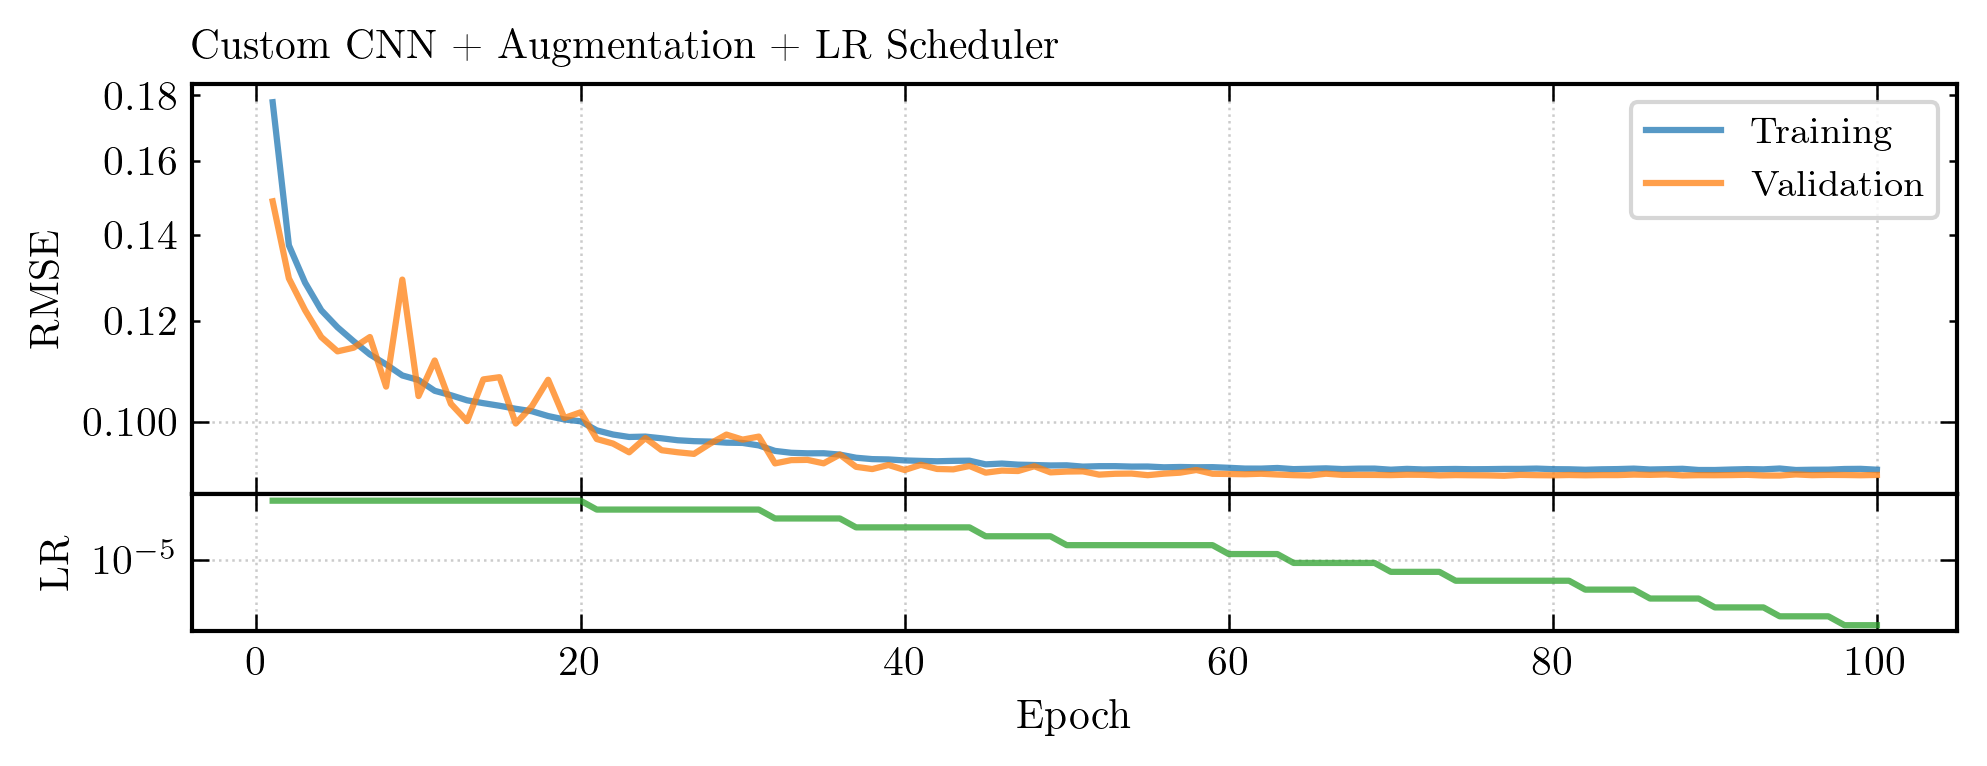

In [5]:
axes = plotters.plot_loss_with_lr(
    aug_result.train_losses, aug_result.val_losses,
    aug_result.learning_rates, f"{BEST_MODEL_NAME} + Augmentation + LR Scheduler",
)
plt.show()

In [6]:
# Save the best augmented model and the aug-only quick-test result
torch.save(aug_result.model_state, "artifacts/best_augmented.pt")
np.savez_compressed(
    "artifacts/augmented_result.npz",
    train_losses=aug_result.train_losses,
    val_losses=aug_result.val_losses,
    best_epoch=aug_result.best_epoch,
    best_val_loss=aug_result.best_val_loss,
    n_parameters=aug_result.n_parameters,
    learning_rates=aug_result.learning_rates,
)

np.savez_compressed(
    "artifacts/aug_only_result.npz",
    train_losses=aug_only_result.train_losses,
    val_losses=aug_only_result.val_losses,
    best_epoch=aug_only_result.best_epoch,
    best_val_loss=aug_only_result.best_val_loss,
    n_parameters=aug_only_result.n_parameters,
    learning_rates=aug_only_result.learning_rates,
)
print("Saved artifacts/best_augmented.pt, artifacts/augmented_result.npz, artifacts/aug_only_result.npz")

Saved artifacts/best_augmented.pt, artifacts/augmented_result.npz, artifacts/aug_only_result.npz


In [ ]:
import pandas as pd

# Centralised model-progression table. The scheduler-only data point lives in
# artifacts/scheduler_result.npz (saved by 05a-scheduler.ipynb) — load from
# disk rather than holding `sched_result` as a notebook-local variable.
baseline_train_rmse = float(split_data["baseline_train_rmse"])
baseline_val_rmse = float(split_data["baseline_val_rmse"])
resnet_data = np.load("artifacts/resnet_result.npz")
sched_data = np.load("artifacts/scheduler_result.npz")

progression = pd.DataFrame([
    {"model": "baseline (mean)",                        "best_val_rmse": baseline_val_rmse, "best_epoch": "-"},
    {"model": "Custom CNN",                              "best_val_rmse": float(custom_data["best_val_loss"]),  "best_epoch": int(custom_data["best_epoch"]) + 1},
    {"model": "ResNet-18",                               "best_val_rmse": float(resnet_data["best_val_loss"]),  "best_epoch": int(resnet_data["best_epoch"]) + 1},
    {"model": f"{BEST_MODEL_NAME} + LR scheduler",       "best_val_rmse": float(sched_data["best_val_loss"]),   "best_epoch": int(sched_data["best_epoch"]) + 1},
    {"model": f"{BEST_MODEL_NAME} + augmentation",       "best_val_rmse": float(aug_only_result.best_val_loss), "best_epoch": int(aug_only_result.best_epoch) + 1},
    {"model": f"{BEST_MODEL_NAME} + scheduler + aug",    "best_val_rmse": float(aug_result.best_val_loss),      "best_epoch": int(aug_result.best_epoch) + 1},
])
progression


,model,best_val_rmse,best_epoch
0,baseline (mean),0.163933,-
1,Custom CNN,0.096997,39
2,ResNet-18,0.096901,95
3,Custom CNN + LR scheduler,0.095451,23
4,Custom CNN + augmentation,0.097040,22
5,Custom CNN + scheduler + aug,0.090768,77


### Did augmentation close the train/val gap?

Compare the loss panel of the augmented run above with the unaugmented Custom CNN curves in `04b-custom-cnn.ipynb`: the validation curve tracks the training curve much more tightly throughout, and the late-epoch divergence that signalled overfitting in the baseline is gone or strongly reduced. Combined with the scheduler, the augmented run reaches the lab manual's "good" target ($\mathrm{RMSE} \le 0.09$) and approaches the "excellent" target ($\le 0.08$). This is the model that we carry forward into `06-evaluation.ipynb` and use to estimate the merger fraction.

### Why is the training curve no longer monotonic?

A second, harder-to-fake diagnostic of "regularisation worked" is visible in the *training* curve itself: with `GpuRandomRotation360` enabled, training RMSE no longer decreases monotonically epoch-to-epoch. This is the canonical signature that the model is not memorising specific `(image, label)` pairs.

In the unaugmented baseline the optimiser sees the exact same training set at every epoch, so a sufficiently expressive model can simply *memorise* it and training RMSE drives monotonically toward zero — generalisation is then bounded only by how much that memorised mapping happens to overlap with held-out galaxies. With $[0, 360)^\circ$ rotation augmentation, every epoch presents a *different* set of rotated images (one fresh angle per image per epoch), so the "training set" the loss is averaged over is effectively a new draw from the augmented distribution at each epoch. The optimiser cannot lower its training loss by memorising individual rotated samples — they will not be re-presented in the same orientation — and is forced to learn the underlying *rotation-invariant* features (arm count, bulge prominence, edge-on aspect ratio) that survive the transformation.

The observable consequence is a training curve that wobbles within a band rather than descending smoothly: at any given epoch, the average loss depends on which random rotation angles happened to be sampled for hard galaxies, and that noise is non-zero even at the asymptote. This is not pathological; it is exactly what we want — it directly demonstrates that the asymptote is being approached on a *distribution* of inputs rather than a single fixed training set, which is the operational definition of "not memorising".

The train–val gap closing (the previous diagnostic) and the training-loss losing monotonicity (this diagnostic) are two faces of the same effect: rotation augmentation has converted a finite-sample problem (49 k galaxies) into a much larger effective sample (49 k × continuum of rotations), and the model now optimises the proper population objective rather than the empirical training-set objective.